In [52]:
using JLD2
using Plots
using LaTeXStrings



In [53]:

data_dir = joinpath(@__DIR__, "data_for_peaks")

all_data = Dict{Float64, Dict{String, Any}}()

sigma_values = [0.0, 1e-7, 1e-6, 1e-5]
file_paths = ["data_eps_sigma_0.0e+00.jld2", "data_eps_sigma_1.0e-07.jld2", "data_eps_sigma_1.0e-06.jld2", "data_eps_sigma_1.0e-05.jld2"]
file_data = [
    try
        load(joinpath(data_dir, file))
    catch e
        println("ERROR loading file: $file")
        println("   -> Details: $e")
        nothing
    end
    for file in file_paths
]

sigma_data = file_data[1:4]  
all_data[sigma_values[1]] = file_data[1]
all_data[sigma_values[2]] = file_data[2]
all_data[sigma_values[3]] = file_data[3]
all_data[sigma_values[4]] = file_data[4]



Dict{String, Any} with 11 entries:
  "s05_avg"     => [0.693147, 0.980832, 1.16316, 1.29669, 1.40205, 1.48906, 1.5…
  "vn_err"      => [0.0, 2.97802e-6, 1.19177e-6, 1.09535e-6, 6.08251e-7, 5.7991…
  "sigma"       => 1.0e-5
  "s0_avg"      => [0.693147, 1.38629, 2.07944, 2.63906, 3.09104, 3.43302, 3.72…
  "s0_err"      => [0.0, 0.0, 4.68111e-16, 0.0, 0.0, 0.046695, 0.0554872, 0.035…
  "avg_arr"     => [2.0, 4.0, 8.0, 14.0, 22.0, 31.1, 41.7, 53.4, 67.1, 79.9  … …
  "s05_err"     => [1.4803e-16, 2.27415e-6, 1.89953e-6, 1.40457e-6, 1.08256e-6,…
  "err_arr"     => [0.0, 0.0, 0.0, 0.0, 0.0, 1.19722, 2.11082, 1.42984, 1.96921…
  "N_range"     => [2, 4, 6, 8, 10, 12, 14, 16, 18, 20  …  62, 64, 66, 68, 70, …
  "vn_avg"      => [0.693147, 0.867564, 1.01823, 1.13807, 1.23587, 1.31806, 1.3…
  "spectra_avg" => [0.5 0.5 … 0.0 0.0; 0.166667 0.666666 … 0.0 0.0; … ; 1.75959…

# BOND DIMENSIONS

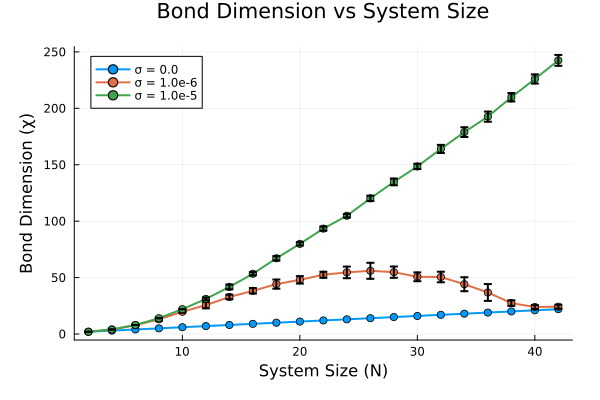

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\bd_spike_more.png"

In [54]:

target_sigmas = [0.0, 1e-6, 1e-5]

p_2d = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm
)

for σ in target_sigmas
    if haskey(all_data, σ)
        data = all_data[σ]
        
        N_vals = data["N_range"]
        bond_dims = data["avg_arr"]
        
        N_vals = 2:2:42
        bond_dims = bond_dims[1:length(N_vals)]

        if σ == 0.0
            err_bars = nothing
        else
            err_bars = data["err_arr"]
        end

        plot!(p_2d, N_vals, bond_dims, 
            errorbar = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    end
end

display(p_2d)
savefig(p_2d, joinpath("images_peak", "bd_spike_more.png"))

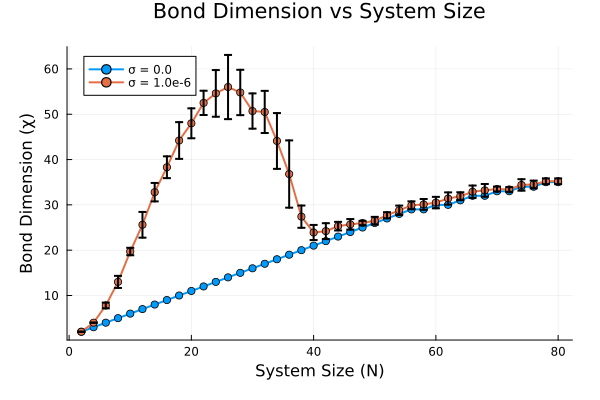

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\bd_spike.png"

In [55]:

target_sigmas = [0.0, 1e-6]

p_2d = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm
)

for σ in target_sigmas
    if haskey(all_data, σ)
        data = all_data[σ]
        
        N_vals = data["N_range"]
        bond_dims = data["avg_arr"]
        
        if σ == 0.0
            err_bars = nothing
        else
            err_bars = data["err_arr"]
        end

        plot!(p_2d, N_vals, bond_dims, 
            errorbar = err_bars,
            label = "σ = $(σ)", 
            marker = :circle, 
            linewidth = 2)
    end
end

display(p_2d)
savefig(p_2d, joinpath("images_peak", "bd_spike.png"))

# ENTROPIES

In [56]:
target_sigmas = [1e-6, 1e-5, 0.0]

sigmas_to_plot = target_sigmas
error_bars = false

false

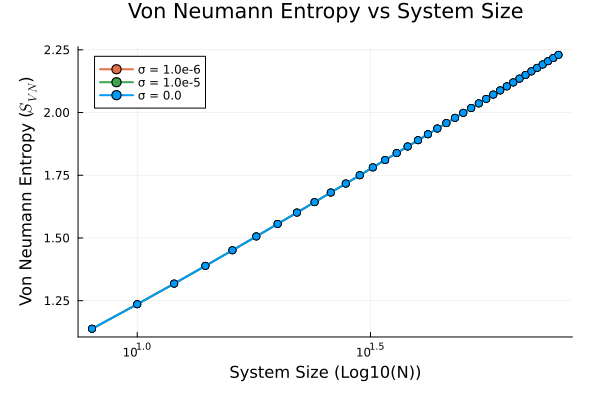

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\s1_ent.png"

In [57]:
target_sigmas = [1e-6, 1e-5, 0.0]

sigmas_to_plot = target_sigmas
error_bars = false

p_2d = plot(
    title = "Von Neumann Entropy vs System Size",
    xlabel = "System Size (Log10(N))",
    ylabel = L"Von Neumann Entropy ($S_{VN}$)",
    legend = :topleft,    
    xaxis = :log10,
    margin = 5Plots.mm
)

for σ in sigmas_to_plot
    if haskey(all_data, σ)
        data = all_data[σ]
        
        N_vals = data["N_range"]
        vn_ent = data["vn_avg"]

        N_vals = N_vals[4:end]
        vn_ent = vn_ent[4:end]
        
        if error_bars == true
            if σ == 0.0
                err_bars = nothing
            else
                err_bars = data["vn_err"]
            end
        else 
            err_bars = nothing
        end

        if σ == 1e-6
            palette_idx = 2  
        elseif σ == 1e-5
            palette_idx = 3 
        else
            palette_idx = 1  
        end


        plot!(p_2d, N_vals, vn_ent, 
              errorbar = err_bars,
              label = "σ = $(σ)", 
              marker = :circle, 
              color = palette_idx,
              linewidth = 2)

    end
end

display(p_2d)
savefig(p_2d, joinpath("images_peak", "s1_ent.png"))

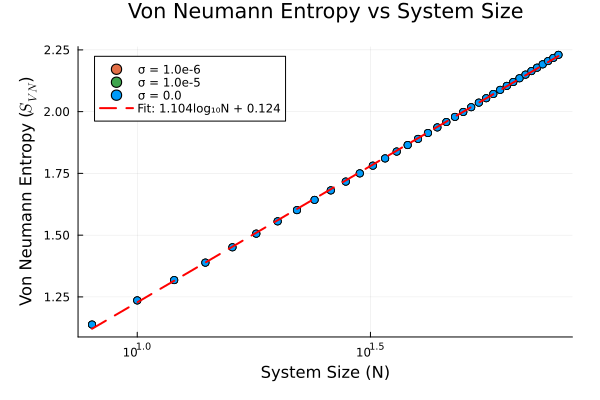

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\s1_ent_with_fit.png"

In [74]:
target_sigmas = [1e-6, 1e-5, 0.0]
sigmas_to_plot = target_sigmas
error_bars = false

p_2d = plot(
    title = "Von Neumann Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Von Neumann Entropy ($S_{VN}$)",
    legend = :topleft,    
    xaxis = :log10,
    margin = 5Plots.mm
)

for σ in sigmas_to_plot
    if haskey(all_data, σ)
        data = all_data[σ]
        
        N_vals = data["N_range"][4:end]
        vn_ent = data["vn_avg"][4:end]
        
        if error_bars == true
            if σ == 0.0
                err_bars = nothing
            else
                err_bars = data["vn_err"][4:end] 
            end
        else 
            err_bars = nothing
        end

        # Set color palette
        if σ == 1e-6
            palette_idx = 2  
        elseif σ == 1e-5
            palette_idx = 3 
        else
            palette_idx = 1  
        end

        # 1. Plot the entropy data as a scatter plot (markers only, no lines)
        scatter!(p_2d, N_vals, vn_ent, 
              yerror = err_bars, # Changed 'errorbar' to 'yerror' (Plots.jl standard)
              label = "σ = $(σ)", 
              marker = :circle, 
              color = palette_idx)

        # 2. Calculate and plot the red fit line for ONLY one sigma (e.g., 0.0)
        if σ == 0.0
            x_for_fit = log10.(N_vals) 
            
            A = hcat(ones(length(x_for_fit)), x_for_fit)
            
            params = A \ vn_ent
            a, b = params[1], params[2]
            
            fit_y = a .+ b .* x_for_fit
            
            # Plot the single fit line in red
            plot!(p_2d, N_vals, fit_y, 
                  label = "Fit: $(round(b, digits=3))log₁₀N + $(round(a, digits=3))", 
                  linestyle = :dash, 
                  color = :red,
                  linewidth = 2)
        end
    end
end

display(p_2d)
savefig(p_2d, joinpath("images_peak", "s1_ent_with_fit.png"))

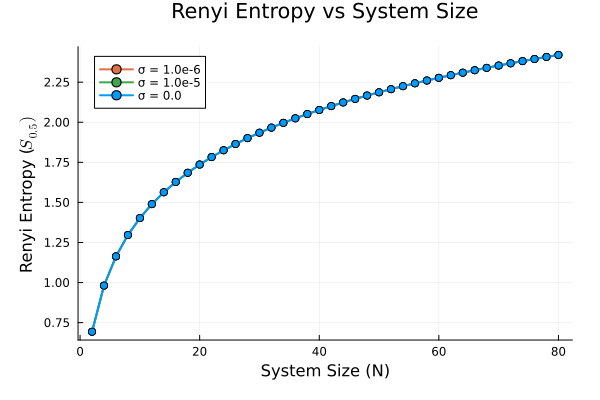

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\s05_ent.png"

In [59]:

p_2d = plot(
    title = "Renyi Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Renyi Entropy ($S_{0.5})$",
    legend = :topleft,    
    margin = 5Plots.mm
)

for σ in sigmas_to_plot
    if haskey(all_data, σ)
        data = all_data[σ]
        
        N_vals = data["N_range"]
        s05_ent = data["s05_avg"]
        

        if error_bars == true
            if σ == 0.0
                err_bars = nothing
            else
                err_bars = data["s05_err"]
            end
        else 
            err_bars = nothing
        end

        if σ == 1e-6
            palette_idx = 2  
        elseif σ == 1e-5
            palette_idx = 3 
        else
            palette_idx = 1  
        end

        plot!(p_2d, N_vals, s05_ent, 
              errorbar = err_bars,
              label = "σ = $(σ)", 
              marker = :circle, 
              color = palette_idx,
              linewidth = 2)

    end
end

display(p_2d)
savefig(p_2d, joinpath("images_peak", "s05_ent.png"))

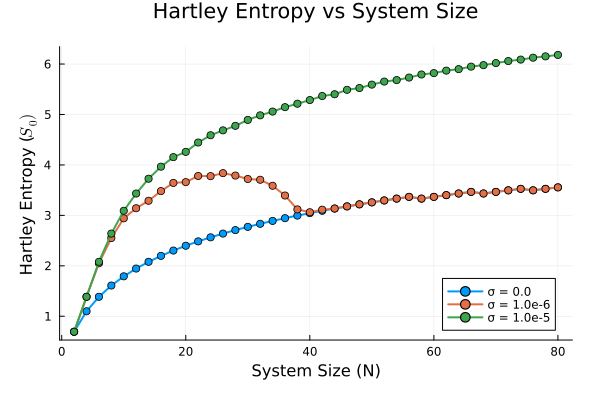

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\s0_ent.png"

In [60]:
target_sigmas = [0.0, 1e-6, 1e-5]
sigmas_to_plot = target_sigmas


p_2d = plot(
    title = "Hartley Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Hartley Entropy ($S_0)$",
    legend = :bottomright,    
    margin = 5Plots.mm
)

for σ in sigmas_to_plot
    if haskey(all_data, σ)
        data = all_data[σ]
        
        N_vals = data["N_range"]
        s0_ent = data["s0_avg"]

        if error_bars == true
            if σ == 0.0
                err_bars = nothing
            else
                err_bars = data["s0_err"]
            end
        else 
            err_bars = nothing
        end

        if σ == 1e-6
            palette_idx = 2  
        elseif σ == 1e-5
            palette_idx = 3 
        else
            palette_idx = 1  
        end
        


        plot!(p_2d, N_vals, s0_ent, 
              errorbar = err_bars,
              label = "σ = $(σ)", 
              marker = :circle, 
              color = palette_idx,
              linewidth = 2)

    end
end

display(p_2d)
savefig(p_2d, joinpath("images_peak", "s0_ent.png"))

# SPECTRA

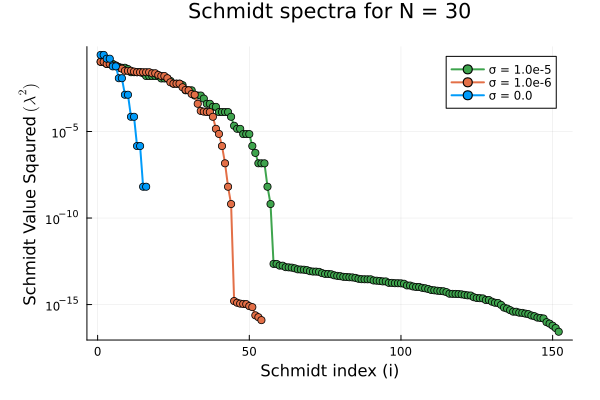

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\Spectra_N=30.png"

In [ ]:

target_N = 30
target_sigmas = [1e-5, 1e-6, 0.0]

p_2d = plot(
    title = "Schmidt spectra for N = $target_N",
    xlabel = "Schmidt index (i)",
    ylabel = L"Schmidt Value Sqaured $(λ^2)$",
    legend = :topright,    
    margin = 5Plots.mm
)

for σ in target_sigmas
    if haskey(all_data, σ)
        data = all_data[σ]
        
        N_vals = data["N_range"]
        spectra = data["spectra_avg"]
        
        n_idx = findfirst(==(target_N), N_vals)
        

        
        spectrum_for_N = sort(spectra[n_idx, :], rev=true) 
        schmidt_indices = 1:length(spectrum_for_N)
        
        valid_mask = spectrum_for_N .> 0
        filtered_spectrum = spectrum_for_N[valid_mask]
        filtered_indices = schmidt_indices[valid_mask]


        if σ == 1e-6
            palette_idx = 2  
        elseif σ == 1e-5
            palette_idx = 3 
        else
            palette_idx = 1  
        end

        
        plot!(p_2d, filtered_indices, filtered_spectrum, 
            yaxis = :log10,
            label = "σ = $(σ)", 
            marker = :circle, 
            color = palette_idx,
            linewidth = 2)
    end
end

display(p_2d)
savefig(p_2d, joinpath("images_peak", "Spectra_N=$target_N.png"))

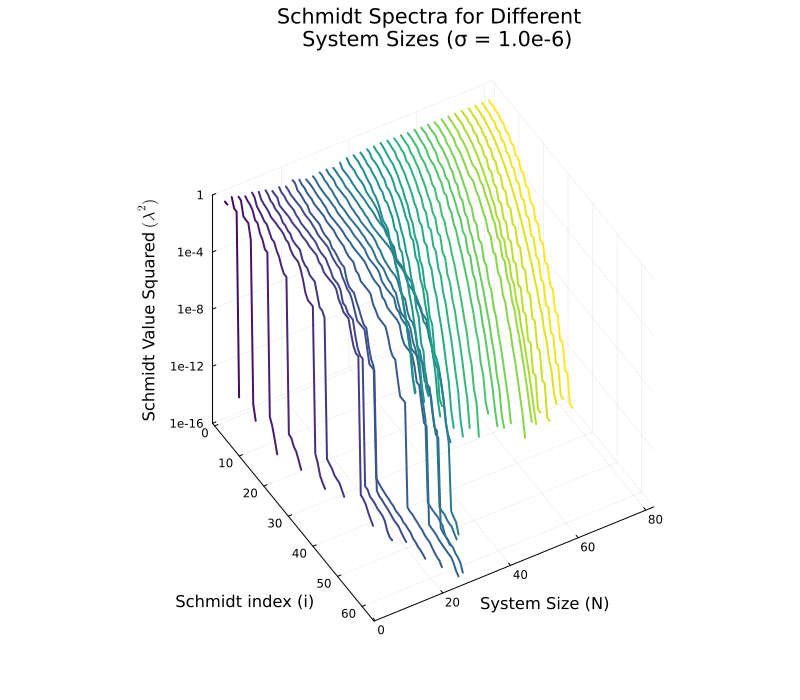

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\spectra_σ=1.0e-6.png"

In [62]:
target_sigma = 1e-6

tick_vals = Float64[-16, -12, -8, -4, 0]
tick_labs = ["1e-16", "1e-12", "1e-8", "1e-4", "1"]

p_3d = plot(
    title = "Schmidt Spectra for Different \n System Sizes (σ = $target_sigma)",
    xlabel = "\nSchmidt index (i)",
    ylabel = "System Size (N)",
    zlabel = L"Schmidt Value Squared $(\lambda^2)$",

    zlims = (-16, 0),               
    zticks = (tick_vals, tick_labs),   

    legend = false, 
    camera = (60, 45), 
    size = (800, 700),
    margin = 5Plots.mm
)

if haskey(all_data, target_sigma)
    data = all_data[target_sigma]
    
    N_vals = data["N_range"]
    spectra = data["spectra_avg"]
    
    for n_idx in 1:length(N_vals)
        N = N_vals[n_idx]
        
        spectrum_for_N = sort(spectra[n_idx, :], rev=true) 
        schmidt_indices = 1:length(spectrum_for_N)
        
        valid_mask = spectrum_for_N .>= 1e-16
        filtered_spectrum = spectrum_for_N[valid_mask]
        filtered_indices = schmidt_indices[valid_mask]
        
        y_vals = fill(N, length(filtered_indices))
        
        plot!(p_3d, filtered_indices, y_vals, log10.(filtered_spectrum), 
            linewidth = 2,
            line_z = N, 
            color = :viridis)
    end

end

display(p_3d)
savefig(p_3d, joinpath("images_peak", "spectra_σ=$(target_sigma).png"))

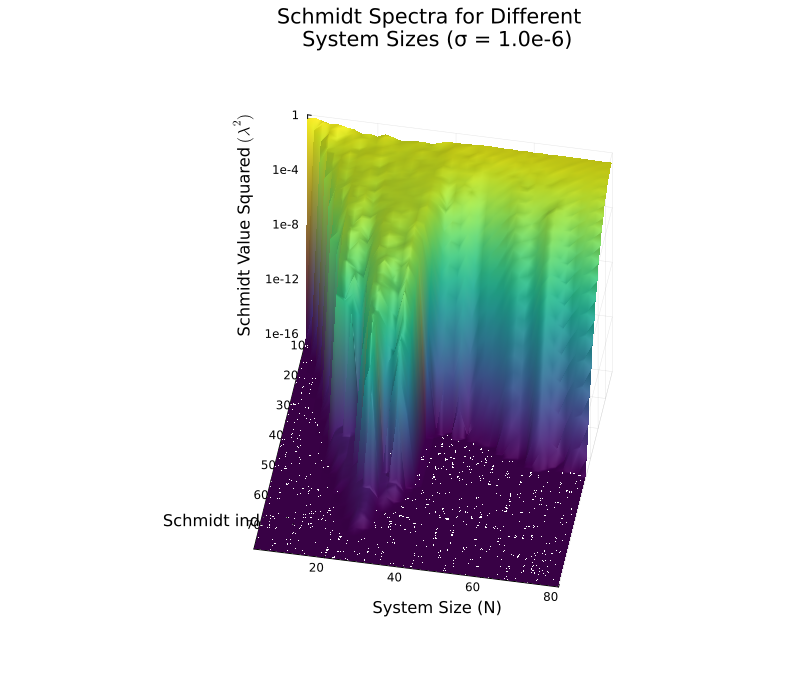

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\spectra_surface_σ=1.0e-6.png"

In [63]:
target_sigma = 1e-6

tick_vals = -16:4:0
tick_labs = ["1e-16", "1e-12", "1e-8", "1e-4", "1"]


p_3d = plot(
    title = "Schmidt Spectra for Different \n System Sizes (σ = $target_sigma)",
    xlabel = "\nSchmidt index (i)",
    ylabel = "System Size (N)",
    zlabel = L"Schmidt Value Squared $(\lambda^2)$",
    
    zlims = (-16, 0),               
    zticks = (tick_vals, tick_labs),  
    colorbar = false,       
    
    camera = (100, 45), 
    size = (800, 700),
    margin = 8Plots.mm
)

if haskey(all_data, target_sigma)
    data = all_data[target_sigma]
    
    N_vals = data["N_range"]
    spectra = data["spectra_avg"]
    
    true_max_len = 0
    for n_idx in 1:length(N_vals)
        spec = typeof(spectra) <: AbstractMatrix ? sort(spectra[n_idx, :], rev=true) : sort(spectra[n_idx], rev=true)
        
        valid_indices = findall(x -> x >= 1e-16, spec)
        if !isempty(valid_indices)
            true_max_len = max(true_max_len, valid_indices[end])
        end
    end
    
    true_max_len = max(1, true_max_len) + 10
    
    X = 1:true_max_len
    Y = N_vals
    
    Z = fill(1e-16, (length(Y), true_max_len))
    
    for n_idx in 1:length(N_vals)
        spec = typeof(spectra) <: AbstractMatrix ? sort(spectra[n_idx, :], rev=true) : sort(spectra[n_idx], rev=true)
        
        for i in 1:min(true_max_len, length(spec))
            val = spec[i]
            Z[n_idx, i] = val < 1e-16 ? 1e-16 : val
        end
    end

    surface!(p_3d, X, Y, log10.(Z), color = :viridis)
end

display(p_3d)
savefig(p_3d, joinpath("images_peak", "spectra_surface_σ=$(target_sigma).png"))

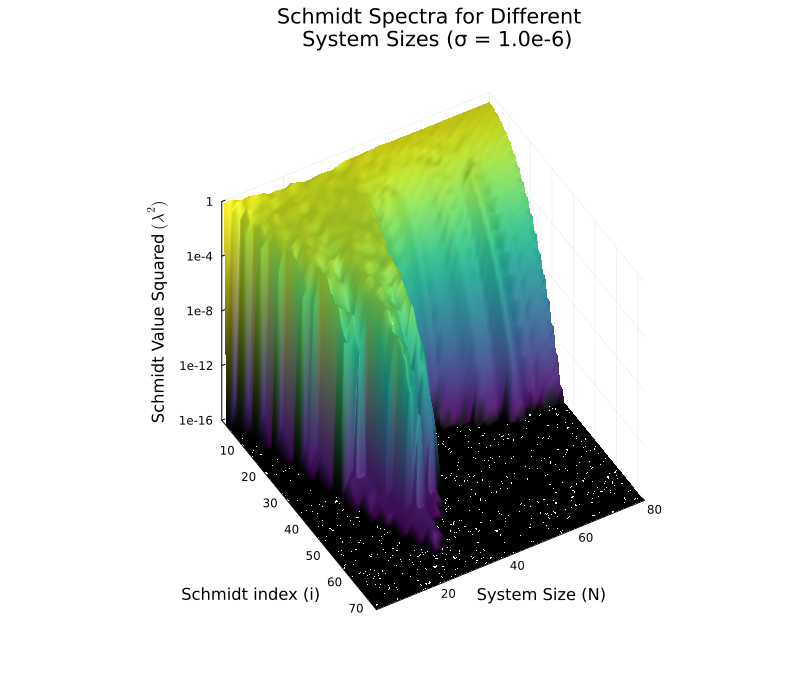

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_peak_analysis\\images_peak\\spectra_surface_black_σ=1.0e-6.png"

In [64]:
target_sigma = 1e-6

tick_vals = -16:4:0
tick_labs = ["1e-16", "1e-12", "1e-8", "1e-4", "1"]


p_3d = plot(
    title = "Schmidt Spectra for Different \n System Sizes (σ = $target_sigma)",
    xlabel = "\nSchmidt index (i)",
    ylabel = "System Size (N)",
    zlabel = L"Schmidt Value Squared $(\lambda^2)$",
    
    zlims = (-16, 0),               
    zticks = (tick_vals, tick_labs),  
    colorbar = false,       
    
    camera = (60, 45), 
    size = (800, 700),
    margin = 8Plots.mm
)

if haskey(all_data, target_sigma)
    data = all_data[target_sigma]
    
    N_vals = data["N_range"]
    spectra = data["spectra_avg"]
    
    true_max_len = 0
    for n_idx in 1:length(N_vals)
        spec = typeof(spectra) <: AbstractMatrix ? sort(spectra[n_idx, :], rev=true) : sort(spectra[n_idx], rev=true)
        
        valid_indices = findall(x -> x >= 1e-16, spec)
        if !isempty(valid_indices)
            true_max_len = max(true_max_len, valid_indices[end])
        end
    end
    
    true_max_len = max(1, true_max_len) + 10
    
    X = 1:true_max_len
    Y = N_vals
    
    Z = fill(1e-16, (length(Y), true_max_len))
    
    for n_idx in 1:length(N_vals)
        spec = typeof(spectra) <: AbstractMatrix ? sort(spectra[n_idx, :], rev=true) : sort(spectra[n_idx], rev=true)
        
        for i in 1:min(true_max_len, length(spec))
            val = spec[i]
            Z[n_idx, i] = val < 1e-16 ? 1e-16 : val
        end
    end

    cg = cgrad(:viridis)
    vir_colors = [RGBA(cg[z]) for z in range(0.0, 1.0, length=200)] 
    
    black_color = RGBA(0.0, 0.0, 0.0, 1.0) 
    
    custom_colors = vcat([black_color, black_color], vir_colors)
    custom_vals = vcat([0.0, 1e-4], range(1.001e-4, stop=1.0, length=length(vir_colors)))
    custom_cmap = cgrad(custom_colors, custom_vals)

    surface!(p_3d, X, Y, log10.(Z), 
        color = custom_cmap,
        clims = (-16, 0) 
    )
end

display(p_3d)
savefig(p_3d, joinpath("images_peak", "spectra_surface_black_σ=$(target_sigma).png"))